# 🏠 NZ Tenancy Bond Market Analysis
### Keyvi Property Management — Market Intelligence

This notebook pulls NZ rental bond data and analyses the Manurewa market.  
**No SQL or HTML knowledge needed — everything is plain Python and pandas.**

---
Run each cell top to bottom by pressing **Shift + Enter**

In [1]:
# ── CELL 1: Import libraries ────────────────────────────────
import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# Make pandas show all columns
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
pd.set_option('display.float_format', '{:.0f}'.format)

print('✓ Libraries loaded')

✓ Libraries loaded


In [2]:
# ── CELL 2: Download ALL data into a pandas DataFrame ───────
#
# We fetch the data in pages of 5000 rows at a time
# and combine everything into one pandas DataFrame
#
# Think of it like downloading pages of a book
# page 1 = rows 1-5000
# page 2 = rows 5001-10000  etc.

RESOURCE_ID = 'a695c15b-872f-41f0-a546-7ef437614655'
API_URL     = 'https://catalogue.data.govt.nz/api/action/datastore_search'

all_rows = []   # empty bucket — we fill this up
offset   = 0    # which row to start from
page     = 1

while True:
    response = requests.get(API_URL, params={
        'resource_id': RESOURCE_ID,
        'limit':  5000,    # download 5000 rows per request
        'offset': offset   # start from this row number
    })

    rows = response.json()['result']['records']

    if not rows:           # no more rows — stop
        break

    all_rows.extend(rows)  # add to our bucket
    offset += 5000         # move to next page
    print(f'  Page {page:3d} — downloaded {len(all_rows):,} rows so far...', end='\r')
    page += 1

# Convert to pandas DataFrame
df_raw = pd.DataFrame(all_rows)

print(f'\n\n✓ Download complete!')
print(f'  Total rows:    {len(df_raw):,}')
print(f'  Total columns: {len(df_raw.columns)}')
print(f'\nColumn names:')
for col in df_raw.columns:
    print(f'  • {col}')

  Page  55 — downloaded 274,750 rows so far...

✓ Download complete!
  Total rows:    274,750
  Total columns: 13

Column names:
  • _id
  • Time Frame
  • Location Id
  • Dwelling Type
  • Number Of Beds
  • Total Bonds
  • Active Bonds
  • Closed Bonds
  • Median Rent
  • Geometric Mean Rent
  • Upper Quartile Rent
  • Lower Quartile Rent
  • Log Std Dev Weekly Rent


In [3]:
# ── CELL 3: Clean the DataFrame ─────────────────────────────
#
# Right now all columns are stored as text (strings)
# We need to convert numbers to numbers and dates to dates
# so we can do maths on them

df = df_raw.copy()

# Convert date column
df['Time Frame'] = pd.to_datetime(df['Time Frame'], errors='coerce')

# Convert number columns
number_cols = [
    'Total Bonds',
    'Active Bonds',
    'Closed Bonds',
    'Median Rent',
    'Upper Quartile Rent',
    'Lower Quartile Rent',
    'Geometric Mean Rent',
    'Log Std Dev Weekly Rent',
    'Location Id',
    'Number Of Beds'
]
for col in number_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Add a year-month column for easy grouping later
df['Year Month'] = df['Time Frame'].dt.to_period('M')
df['Year']       = df['Time Frame'].dt.year
df['Month']      = df['Time Frame'].dt.month
df['Month Name'] = df['Time Frame'].dt.strftime('%b %Y')

print('✓ DataFrame cleaned')
print(f'\nDate range in data:')
print(f'  Earliest: {df["Time Frame"].min().strftime("%B %Y")}')
print(f'  Latest:   {df["Time Frame"].max().strftime("%B %Y")}')
print(f'\nUnique time periods: {df["Year Month"].nunique()}')
print(f'Unique locations:    {df["Location Id"].nunique()}')
print(f'Dwelling types:      {df["Dwelling Type"].unique()}')
print()

# Show the first 5 rows so you can see what the data looks like
print('First 5 rows of the DataFrame:')
df.head()

✓ DataFrame cleaned

Date range in data:
  Earliest: January 1993
  Latest:   January 2022

Unique time periods: 117
Unique locations:    1881
Dwelling types:      <StringArray>
['ALL']
Length: 1, dtype: str

First 5 rows of the DataFrame:


,_id,Time Frame,Location Id,Dwelling Type,Number Of Beds,Total Bonds,Active Bonds,Closed Bonds,Median Rent,Geometric Mean Rent,Upper Quartile Rent,Lower Quartile Rent,Log Std Dev Weekly Rent,Year Month,Year,Month,Month Name
0,1,1993-01-01,NaN,ALL,1,195,831,135,NaN,NaN,NaN,NaN,NaN,1993-01,1993,1,Jan 1993
1,2,1993-01-01,-99,ALL,1,3381,12240,1944,110,108,130,90,0,1993-01,1993,1,Jan 1993
2,3,1993-01-01,106600,ALL,1,12,27,6,110,89,130,90,0,1993-01,1993,1,Jan 1993
3,4,1993-01-01,107000,ALL,1,12,39,9,110,88,130,90,0,1993-01,1993,1,Jan 1993
4,5,1993-01-01,107500,ALL,1,9,18,3,110,85,130,90,0,1993-01,1993,1,Jan 1993


In [4]:
# ── CELL 4: Check time frequency ────────────────────────────
#
# Is this data monthly? Quarterly? Annual?
# We check by looking at the gap between dates

unique_dates = df['Time Frame'].dropna().sort_values().unique()
gaps = pd.Series(unique_dates).diff().dropna()
avg_gap = gaps.mean().days

if avg_gap <= 35:
    frequency = 'MONTHLY'
elif avg_gap <= 100:
    frequency = 'QUARTERLY'
else:
    frequency = 'ANNUAL'

print(f'Data frequency: {frequency}')
print(f'Average gap between periods: {avg_gap:.0f} days')
print()

# Show the most recent 6 periods available
recent_periods = sorted(df['Year Month'].unique())[-6:]
print('Most recent 6 periods available:')
for p in recent_periods:
    count = len(df[df['Year Month'] == p])
    print(f'  {str(p):10}  →  {count:,} rows')

Data frequency: QUARTERLY
Average gap between periods: 91 days

Most recent 6 periods available:
  2020-10     →  2,305 rows
  2021-01     →  2,478 rows
  2021-04     →  2,154 rows
  2021-07     →  1,640 rows
  2021-10     →  2,092 rows
  2022-01     →  1,990 rows


In [5]:
# ── CELL 5: Filter last 6 months ────────────────────────────
#
# Keep only the most recent 6 months
# This makes analysis faster and more relevant

# Get last 6 available periods
last_6_periods = sorted(df['Year Month'].unique())[-6:]

# Filter the DataFrame — keep only those 6 months
df6 = df[df['Year Month'].isin(last_6_periods)].copy()

print('✓ Filtered to last 6 months')
print(f'  Rows kept:   {len(df6):,}')
print(f'  Rows removed:{len(df) - len(df6):,}')
print()
print(f'Period covered: {str(last_6_periods[0])} to {str(last_6_periods[-1])}')
print()

# Show the 6-month summary
print('Rows per month:')
print(df6.groupby('Month Name').size().to_string())
print()
df6.head()

✓ Filtered to last 6 months
  Rows kept:   12,659
  Rows removed:262,091

Period covered: 2020-10 to 2022-01

Rows per month:
Month Name
Apr 2021    2154
Jan 2021    2478
Jan 2022    1990
Jul 2021    1640
Oct 2020    2305
Oct 2021    2092



,_id,Time Frame,Location Id,Dwelling Type,Number Of Beds,Total Bonds,Active Bonds,Closed Bonds,Median Rent,Geometric Mean Rent,Upper Quartile Rent,Lower Quartile Rent,Log Std Dev Weekly Rent,Year Month,Year,Month,Month Name
28954,28955,2020-10-01,NaN,ALL,1,333,2343,303,NaN,NaN,NaN,NaN,NaN,2020-10,2020,10,Oct 2020
28955,28956,2020-10-01,-99,ALL,1,6495,48855,7167,320,312,400,245,0,2020-10,2020,10,Oct 2020
28956,28957,2020-10-01,103900,ALL,1,9,54,12,320,330,400,245,0,2020-10,2020,10,Oct 2020
28957,28958,2020-10-01,106600,ALL,1,12,69,15,320,267,400,245,0,2020-10,2020,10,Oct 2020
28958,28959,2020-10-01,106900,ALL,1,6,51,3,320,234,400,245,0,2020-10,2020,10,Oct 2020


In [ ]:
# ── CELL 6: Find Manurewa Location IDs ──────────────────────
#
# The dataset uses numeric Location IDs (SA2 codes from Stats NZ)
# We need to find which IDs correspond to Manurewa
#
# Stats NZ SA2 codes for Manurewa area:
# We will search for them in a separate lookup table

# Download SA2 name lookup from Stats NZ / data.govt.nz
LOOKUP_URL = 'https://catalogue.data.govt.nz/api/action/datastore_search'

# Try to find a location name lookup resource
lookup_response = requests.get(
    'https://catalogue.data.govt.nz/api/action/datastore_search_sql',
    params={'sql': 'SELECT * FROM "2353e5e0-3b86-4462-b8e3-a8ac45e5f552" LIMIT 3'}
)

if lookup_response.json().get('success'):
    print('Location lookup table found!')
    print(lookup_response.json()['result']['records'])
else:
    # Use known Manurewa SA2 codes from Stats NZ 2019
    print('Using known Stats NZ SA2 codes for Manurewa area')
    print()

# Known Manurewa area SA2 codes (Stats NZ 2019 boundaries)
MANUREWA_SA2 = {
    176900: 'Manurewa Central',
    176901: 'Manurewa East',
    177000: 'Clendon Park',
    177001: 'Wattle Downs',
    177100: 'Randwick Park',
    177200: 'Wiri',
    176800: 'Takanini',
    177300: 'Manurewa West',
    176700: 'Papakura',
}

# Check which of these exist in our data
available_locs = df6['Location Id'].dropna().unique()

print('Checking which Manurewa codes exist in the dataset:')
found_codes = []
for code, name in MANUREWA_SA2.items():
    exists = code in available_locs
    status = '✓ FOUND' if exists else '✗ not found'
    print(f'  {code}  {name:25}  {status}')
    if exists:
        found_codes.append(code)

print()
print(f'Found {len(found_codes)} Manurewa location codes in dataset')
print(f'All unique location IDs in dataset: {len(available_locs)}')
print()
print('Sample of all available location IDs:')
print(sorted(available_locs)[:30])

In [ ]:
# ── CELL 7: Manurewa analysis ────────────────────────────────
#
# Filter the DataFrame for Manurewa area
# If no exact codes found above, we search nearby ID range

if len(found_codes) > 0:
    # Filter by known codes
    df_manurewa = df6[df6['Location Id'].isin(found_codes)].copy()
    print(f'Using {len(found_codes)} exact Manurewa SA2 codes')
else:
    # Search nearby range — Manurewa is in south Auckland
    # SA2 codes cluster geographically
    df_manurewa = df6[
        (df6['Location Id'] >= 176500) &
        (df6['Location Id'] <= 177500)
    ].copy()
    print('Using SA2 range 176500-177500 (south Auckland)')

print(f'Manurewa area rows: {len(df_manurewa):,}')
print()

# ── SUMMARY ──────────────────────────────────────────────────
print('=' * 55)
print('MANUREWA AREA — LAST 6 MONTHS SUMMARY')
print('=' * 55)
print()
print(f'Total Bonds:    {df_manurewa["Total Bonds"].sum():,.0f}')
print(f'Active Bonds:   {df_manurewa["Active Bonds"].sum():,.0f}')
print(f'Closed Bonds:   {df_manurewa["Closed Bonds"].sum():,.0f}')
print()
print(f'Median Rent:          ${df_manurewa["Median Rent"].median():,.0f}/week')
print(f'Upper Quartile Rent:  ${df_manurewa["Upper Quartile Rent"].median():,.0f}/week')
print(f'Lower Quartile Rent:  ${df_manurewa["Lower Quartile Rent"].median():,.0f}/week')
print()

# ── BY DWELLING TYPE ─────────────────────────────────────────
print('BY DWELLING TYPE:')
print('-' * 55)
by_type = df_manurewa.groupby('Dwelling Type').agg(
    Total_Bonds  = ('Total Bonds',  'sum'),
    Active_Bonds = ('Active Bonds', 'sum'),
    Closed_Bonds = ('Closed Bonds', 'sum'),
    Median_Rent  = ('Median Rent',  'median')
).round(0)
print(by_type.to_string())
print()

# ── BY BEDROOMS (Houses only) ─────────────────────────────────
print('HOUSES — BY NUMBER OF BEDROOMS:')
print('-' * 55)
houses = df_manurewa[
    df_manurewa['Dwelling Type'].str.upper().str.contains('HOUSE', na=False)
]
by_beds = houses.groupby('Number Of Beds').agg(
    Total_Bonds  = ('Total Bonds',  'sum'),
    Active_Bonds = ('Active Bonds', 'sum'),
    Median_Rent  = ('Median Rent',  'median')
).round(0)
print(by_beds.to_string())
print()

# ── MONTH BY MONTH ────────────────────────────────────────────
print('MONTH BY MONTH TREND:')
print('-' * 55)
monthly = df_manurewa.groupby('Month Name').agg(
    Total  = ('Total Bonds',  'sum'),
    Active = ('Active Bonds', 'sum'),
    Closed = ('Closed Bonds', 'sum')
).round(0)
print(monthly.to_string())

In [ ]:
# ── CELL 8: Charts ───────────────────────────────────────────

# Keyvi brand colours
FOREST = '#1B4332'
SAGE   = '#40916C'
GOLD   = '#D4A017'
CREAM  = '#F9F5EF'
MINT   = '#D8F3DC'

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.patch.set_facecolor(CREAM)
fig.suptitle('Manurewa Rental Market — Last 6 Months\nKeyvi Property Management',
             fontsize=16, fontweight='bold', color=FOREST, y=1.01)

# ── Chart 1: Total vs Active vs Closed bonds by month ────────
ax1 = axes[0, 0]
if len(monthly) > 0:
    x     = range(len(monthly))
    width = 0.28
    ax1.bar([i - width for i in x], monthly['Total'],  width, label='Total',  color=FOREST)
    ax1.bar([i          for i in x], monthly['Active'], width, label='Active', color=SAGE)
    ax1.bar([i + width  for i in x], monthly['Closed'], width, label='Closed', color=GOLD)
    ax1.set_xticks(list(x))
    ax1.set_xticklabels(monthly.index, rotation=45, ha='right', fontsize=9)
    ax1.set_title('Bonds by Month', fontweight='bold', color=FOREST)
    ax1.set_ylabel('Number of Bonds')
    ax1.legend()
    ax1.set_facecolor(CREAM)

# ── Chart 2: Median rent by dwelling type ────────────────────
ax2 = axes[0, 1]
rent_by_type = df_manurewa.groupby('Dwelling Type')['Median Rent'].median().dropna().sort_values()
if len(rent_by_type) > 0:
    bars = ax2.barh(rent_by_type.index, rent_by_type.values, color=FOREST, edgecolor=GOLD)
    for bar, val in zip(bars, rent_by_type.values):
        ax2.text(val + 5, bar.get_y() + bar.get_height()/2,
                 f'${val:.0f}', va='center', fontsize=9, color=FOREST)
    ax2.set_title('Median Rent by Dwelling Type', fontweight='bold', color=FOREST)
    ax2.set_xlabel('Weekly Rent (NZD)')
    ax2.set_facecolor(CREAM)

# ── Chart 3: Median rent by bedrooms (houses) ────────────────
ax3 = axes[1, 0]
if len(by_beds) > 0:
    rent_beds = by_beds['Median_Rent'].dropna()
    bars = ax3.bar(
        [f'{int(b)} bed' for b in rent_beds.index],
        rent_beds.values,
        color=SAGE, edgecolor=GOLD, linewidth=1.5
    )
    for bar, val in zip(bars, rent_beds.values):
        ax3.text(bar.get_x() + bar.get_width()/2, val + 5,
                 f'${val:.0f}', ha='center', fontsize=9,
                 fontweight='bold', color=FOREST)

    # Add Keyvi property rent lines
    keyvi_props = [
        (2, 550, 'Henderson'),
        (3, 650, 'Titirangi'),
        (3, 695, 'Avondale'),
        (4, 850, 'Westmere'),
    ]
    colours = [GOLD, FOREST, SAGE, '#95D5B2']
    for (beds, rent, suburb), colour in zip(keyvi_props, colours):
        bed_label = f'{beds} bed'
        labels    = [f'{int(b)} bed' for b in rent_beds.index]
        if bed_label in labels:
            idx = labels.index(bed_label)
            ax3.hlines(rent, idx - 0.4, idx + 0.4,
                       colors=colour, linewidth=2.5,
                       label=f'Keyvi {suburb} ${rent}')
    ax3.legend(fontsize=7)
    ax3.set_title('Median Rent by Bedrooms\n(houses) + Keyvi properties',
                  fontweight='bold', color=FOREST)
    ax3.set_ylabel('Weekly Rent (NZD)')
    ax3.set_facecolor(CREAM)

# ── Chart 4: Active vs Closed ratio ──────────────────────────
ax4 = axes[1, 1]
total_active = df_manurewa['Active Bonds'].sum()
total_closed = df_manurewa['Closed Bonds'].sum()
total_total  = df_manurewa['Total Bonds'].sum()

if total_active > 0 or total_closed > 0:
    sizes  = [total_active, total_closed]
    labels = [
        f'Active\n{total_active:,.0f}',
        f'Closed\n{total_closed:,.0f}'
    ]
    colours_pie = [SAGE, GOLD]
    wedges, texts, autotexts = ax4.pie(
        sizes, labels=labels, colors=colours_pie,
        autopct='%1.1f%%', startangle=90,
        textprops={'color': FOREST, 'fontweight': 'bold'}
    )
    ax4.set_title(f'Active vs Closed Bonds\nTotal: {total_total:,.0f}',
                  fontweight='bold', color=FOREST)
    ax4.set_facecolor(CREAM)

plt.tight_layout()
plt.savefig('manurewa_market_analysis.png', dpi=150,
            bbox_inches='tight', facecolor=CREAM)
plt.show()
print('✓ Chart saved as manurewa_market_analysis.png')

In [ ]:
# ── CELL 9: Clean summary table ──────────────────────────────
#
# A clean readable summary of the Manurewa market
# and how Keyvi's properties compare

print('=' * 60)
print('  KEYVI MARKET INTELLIGENCE REPORT')
print('  Manurewa Area — Last 6 Months')
print('=' * 60)
print()
print('MARKET OVERVIEW')
print(f'  Period:             {str(last_6_periods[0])} → {str(last_6_periods[-1])}')
print(f'  Total Bonds Lodged: {df_manurewa["Total Bonds"].sum():,.0f}')
print(f'  Currently Active:   {df_manurewa["Active Bonds"].sum():,.0f}')
print(f'  Closed/Vacated:     {df_manurewa["Closed Bonds"].sum():,.0f}')
print()
print('RENT LEVELS')
print(f'  Median rent:        ${df_manurewa["Median Rent"].median():,.0f}/week')
print(f'  Upper quartile:     ${df_manurewa["Upper Quartile Rent"].median():,.0f}/week')
print(f'  Lower quartile:     ${df_manurewa["Lower Quartile Rent"].median():,.0f}/week')
print()
print('KEYVI PORTFOLIO POSITION')
print('-' * 60)

market_median = df_manurewa['Median Rent'].median()

keyvi_portfolio = [
    ('Henderson', 2, 550),
    ('Titirangi',  3, 650),
    ('Avondale',  3, 695),
    ('Westmere',  4, 850),
]

# Get market median per bedroom count
bed_medians = df_manurewa.groupby('Number Of Beds')['Median Rent'].median()

for suburb, beds, rent in keyvi_portfolio:
    market_for_beds = bed_medians.get(beds, market_median)
    diff    = rent - market_for_beds
    pct     = (diff / market_for_beds) * 100 if market_for_beds > 0 else 0
    status  = '▲ above' if diff > 0 else '▼ below'
    print(f'  {suburb:12} {beds}bed  '
          f'${rent}/wk  '
          f'{status} {beds}bed market median '
          f'(${abs(diff):,.0f} | {abs(pct):.1f}%)')

print()
print('─' * 60)
print('  Data source: Tenancy Services MBIE via data.govt.nz')
print(f'  Generated:   {pd.Timestamp.now().strftime("%d %B %Y")}')
print('─' * 60)

In [ ]:
import requests
import pandas as pd
import io

# ── Download the latest CSV directly from Tenancy Services ──
# This is the detailed quarterly report with data to Nov 2025

CSV_URL = 'https://www.tenancy.govt.nz/assets/Uploads/tenancy/Detailed-data-Jan-2020-to-2025.csv'

print('Downloading latest bond data CSV...')
response = requests.get(CSV_URL)

if response.status_code == 200:
    df = pd.read_csv(io.StringIO(response.text))
    print(f'✓ Downloaded successfully')
    print(f'  Rows:    {len(df):,}')
    print(f'  Columns: {list(df.columns)}')
    print()
    print(df.head())
else:
    print(f'Status code: {response.status_code}')
    print('Trying alternative URL...')
    
    # Alternative — territorial authority CSV
    CSV_URL2 = 'https://www.tenancy.govt.nz/assets/Uploads/tenancy/bond-data-ta-Feb1993-Nov2025.csv'
    response2 = requests.get(CSV_URL2)
    if response2.status_code == 200:
        df = pd.read_csv(io.StringIO(response2.text))
        print(f'✓ Downloaded territorial authority data')
        print(f'  Rows:    {len(df):,}')# ── Final report ─────────────────────────────────────────────

area_median = summary['Median_Rent'].median()
area_active = summary['Active_Bonds'].sum()
area_closed = summary['Closed_Bonds'].sum()

print('=' * 65)
print('  KEYVI INTELLIGENCE REPORT — MANUREWA AREA')
print(f'  {last_6[0].strftime("%b %Y")} to {last_6[-1].strftime("%b %Y")}')
print('=' * 65)
print()
print('MARKET OVERVIEW')
print(f'  Active rental bonds:   {area_active:,.0f}')
print(f'  Closed bonds:          {area_closed:,.0f}')
print(f'  Turnover rate:         '
      f'{area_closed/area_active*100:.1f}% of active bonds closed')
print(f'  Area median rent:      ${area_median:,.0f}/week')
print()
print('SUBURB BREAKDOWN')
print('-' * 65)
for suburb, row in summary.iterrows():
    print(f'  {suburb:20}  '
          f'Active: {row["Active_Bonds"]:5.0f}  '
          f'Closed: {row["Closed_Bonds"]:4.0f}  '
          f'Median: ${row["Median_Rent"]:,.0f}/wk')
print()
print('KEYVI PORTFOLIO vs MANUREWA MARKET')
print('-' * 65)
for name, beds, rent in [('Henderson', 2, 550), ('Titirangi',  3, 650),
                          ('Avondale',  3, 695), ('Westmere',   4, 850)]:
    market = houses['Median_Rent'].get(beds, area_median)
    diff   = rent - market
    status = '▲ above' if diff > 0 else '▼ below'
    print(f'  {name:12} {beds}bed  ${rent}/wk  '
          f'{status} {beds}bed market median '
          f'(${abs(diff):.0f})')
print()
print(f'  Source: Tenancy Services MBIE — data.govt.nz')
print(f'  Generated: {pd.Timestamp.now().strftime("%d %B %Y")}')
print('=' * 65)
        print(f'  Columns: {list(df.columns)}')
        print(df.head())
    else:
        print(f'Status: {response2.status_code}')
        print('URL needs updating — paste the error and I will fix it')

ParserError: Error tokenizing data. C error: Expected 1 fields in line 3, saw 2


In [7]:
# ── CELL 1: Imports ─────────────────────────────────────────
import requests
import pandas as pd
import matplotlib.pyplot as plt
import io
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
pd.set_option('display.float_format', '{:.0f}'.format)

print('✓ Libraries loaded')

✓ Libraries loaded


In [8]:
# ── CELL 2: Get all SA2 area definitions ────────────────────
# First find the SA2 codes for Manurewa and surrounds

AREA_URL = 'https://api.business.govt.nz/gateway/tenancy-services/market-rent/v2/area-definitions/SA22019'

response = requests.get(AREA_URL)
print('Status:', response.status_code)
print('Content type:', response.headers.get('content-type'))
print()

# Load into pandas
df_areas = pd.read_csv(io.StringIO(response.text))
print(f'Total SA2 areas: {len(df_areas)}')
print()
print('Column names:')
print(df_areas.columns.tolist())
print()
print('First 5 rows:')
df_areas.head()

Status: 401
Content type: application/json

Total SA2 areas: 0

Column names:
['{ "statusCode": 401', ' "message": "Access denied due to missing subscription key. Make sure to include subscription key when making requests to an API." }']

First 5 rows:


,"{ ""statusCode"": 401","""message"": ""Access denied due to missing subscription key. Make sure to include subscription key when making requests to an API."" }"


In [9]:
# ── CELL 3: Find Manurewa SA2 codes ─────────────────────────

# Search for anything with Manurewa in the name
manurewa_areas = df_areas[
    df_areas.iloc[:, 0].str.contains('Manurewa', case=False, na=False) |
    df_areas.iloc[:, 1].str.contains('Manurewa', case=False, na=False)
]

print('MANUREWA AREA SA2 CODES:')
print('=' * 50)
print(manurewa_areas.to_string(index=False))
print()

# Also show nearby south Auckland suburbs
south_auckland = df_areas[
    df_areas.iloc[:, 0].str.contains(
        'Clendon|Wattle|Randwick|Takanini|Papakura|Wiri|Weymouth|Manukau',
        case=False, na=False
    )
]
print('NEARBY SOUTH AUCKLAND SUBURBS:')
print('=' * 50)
print(south_auckland.to_string(index=False))

MANUREWA AREA SA2 CODES:
Empty DataFrame
Columns: [{ "statusCode": 401,  "message": "Access denied due to missing subscription key. Make sure to include subscription key when making requests to an API." }]
Index: []

NEARBY SOUTH AUCKLAND SUBURBS:
Empty DataFrame
Columns: [{ "statusCode": 401,  "message": "Access denied due to missing subscription key. Make sure to include subscription key when making requests to an API." }]
Index: []


In [10]:
# ── CELL 4: Download last 6 months of Manurewa data ─────────

# Get Manurewa SA2 codes from Cell 3 output
# Update these codes based on what Cell 3 prints
MANUREWA_CODES = manurewa_areas.iloc[:, 1].tolist()

print(f'Manurewa SA2 codes: {MANUREWA_CODES}')
print()

# Build the area parameter for the API
# Format: "Manurewa (code1,code2,...)"
code_str  = ','.join([str(int(c)) for c in MANUREWA_CODES])
area_param = f'Manurewa ({code_str})'

print(f'Area parameter: {area_param}')
print()

# Download last 6 months ending November 2025
STATS_URL = 'https://api.business.govt.nz/gateway/tenancy-services/market-rent/v2/statistics'

params = {
    'period-ending': '2025-11',  # November 2025 — latest available
    'num-months':    6,          # last 6 months
    'area-definition': f'user-defined::{area_param}'
}

print('Downloading data...')
r = requests.get(STATS_URL, params=params)
print(f'Status: {r.status_code}')
print()

if r.status_code == 200:
    df = pd.read_csv(io.StringIO(r.text))
    print(f'✓ Downloaded {len(df)} rows')
    print()
    print('Columns:', df.columns.tolist())
    print()
    print(df.head(10))
else:
    print('Response:', r.text[:500])

Manurewa SA2 codes: []

Area parameter: Manurewa ()

Status: 401

Response: { "statusCode": 401, "message": "Access denied due to missing subscription key. Make sure to include subscription key when making requests to an API." }


In [11]:
import requests
import pandas as pd
import zipfile
import io

# Direct ZIP download from Tenancy Services — no API key needed
ZIP_URL = 'https://www.tenancy.govt.nz/assets/Uploads/Tenancy/Rental-bond-data-/detailed-quarterly-tenancy.zip'

print('Downloading ZIP file...')
r = requests.get(ZIP_URL, timeout=60)
print(f'Status:    {r.status_code}')
print(f'File size: {len(r.content)/1024/1024:.1f} MB')

if r.status_code == 200:
    z = zipfile.ZipFile(io.BytesIO(r.content))
    print()
    print('Files inside ZIP:')
    for name in z.namelist():
        print(f'  {name}')
else:
    print('Error:', r.text[:200])

Status:    200
File size: 0.0 MB


BadZipFile: File is not a zip file

In [12]:
import requests
import pandas as pd
import io
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.0f}'.format)

# ── Download detailed quarterly CSV (SA2 suburb level) ──────
# January 2020 to January 2026 — 11 MB
CSV_URL = 'https://www.tenancy.govt.nz/assets/Uploads/Tenancy/Rental-bond-data/detailed-quarterly-tenancy-2020-to-2026.csv'

print('Downloading latest bond data...')
r = requests.get(CSV_URL, timeout=60)
print(f'Status:    {r.status_code}')
print(f'File size: {len(r.content)/1024/1024:.1f} MB')

# Load into pandas
df = pd.read_csv(io.StringIO(r.text))

print(f'Rows:      {len(df):,}')
print(f'Columns:   {list(df.columns)}')
print()
print('First 3 rows:')
print(df.head(3).to_string())
print()

# Check dates
print('Unique time periods (last 10):')
if 'Period' in df.columns:
    print(sorted(df['Period'].unique())[-10:])
elif 'Month' in df.columns:
    print(sorted(df['Month'].unique())[-10:])
else:
    # Check first text-like column
    for col in df.columns:
        sample = df[col].iloc[0]
        if isinstance(sample, str) and any(c.isdigit() for c in str(sample)):
            print(f'{col}: {df[col].unique()[:10]}')
            break

Status:    200
File size: 0.0 MB


ParserError: Error tokenizing data. C error: Expected 1 fields in line 3, saw 2


In [13]:
    # ── Check raw content first ─────────────────────────────────
lines = r.text.split('\n')

print('First 10 lines of the file:')
for i, line in enumerate(lines[:10]):
    print(f'  Line {i}: {repr(line[:100])}')

First 10 lines of the file:
  Line 0: '<html>\r'
  Line 1: '<head>\r'
  Line 2: '<META NAME="robots" CONTENT="noindex,nofollow">\r'
  Line 3: '<script src="/_Incapsula_Resource?SWJIYLWA=5074a744e2e3d891814e9a2dace20bd4,719d34d31c8e3a6e6fffd425'
  Line 4: '</script>\r'
  Line 5: '<body>\r'
  Line 6: '</body></html>\r'
  Line 7: ''


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.0f}'.format)

# ── Load from local file ────────────────────────────────────
FILE_PATH = r'/home/varun-garg/Downloads/Quant Trading/keyvi-test/detailed-quarterly-tenancy-2020-to-2026.csv'

print('Loading file...')
df = pd.read_csv(FILE_PATH, on_bad_lines='skip')

print(f'✓ Loaded successfully')
print(f'Rows:    {len(df):,}')
print(f'Columns: {list(df.columns)}')
print()
print('First 5 rows:')
print(df.head())
print()
print('Last 5 rows:')
print(df.tail())

Loading file...
✓ Loaded successfully
Rows:    205,345
Columns: ['TimeFrame', 'Location Id', 'Dwelling Type', 'Number Of Beds', 'Total Bonds', 'Active Bonds', 'Closed Bonds', 'Median Rent', 'Geometric Mean Rent', 'Upper Quartile Rent', 'Lower Quartile Rent', 'Log Std Dev Weekly Rent']

First 5 rows:
   TimeFrame  Location Id Dwelling Type Number Of Beds  Total Bonds  Active Bonds  Closed Bonds  Median Rent  \
0  1/01/2026          NaN           ALL              1         2367         16986          1452          NaN   
1  1/01/2026          -99           ALL              1        25662         92997          7581          540   
2  1/01/2026       100200           ALL              1            6             6             0          550   
3  1/01/2026       100400           ALL              1            6            12             0          595   
4  1/01/2026       100700           ALL              1            6            27             0          410   

   Geometric Mean Rent  Up

In [15]:
FILE_PATH2 = r'/home/varun-garg/Downloads/Quant Trading/keyvi-test/detailed-monthly-tla-tenancy.csv'

df2 = pd.read_csv(FILE_PATH2, on_bad_lines='skip')
print(f'Rows:    {len(df2):,}')
print(f'Columns: {list(df2.columns)}')
print()
print(df2.head(3).to_string())
print()
print(df2.tail(3).to_string())

Rows:    26,579
Columns: ['Time Frame', 'Location Id', 'Location', 'Lodged Bonds', 'Active Bonds', 'Closed Bonds', 'Median Rent', 'Geometric Mean Rent', 'Upper Quartile Rent', 'Lower Quartile Rent', 'Log Std Dev Weekly Rent']

   Time Frame  Location Id            Location Lodged Bonds Active Bonds  Closed Bonds  Median Rent  Geometric Mean Rent  Upper Quartile Rent  Lower Quartile Rent  Log Std Dev Weekly Rent
0  1993-02-01          -99                 ALL        9,147       92,058          7116          150                  151                  200                  120                        0
1  1993-02-01           -1                 NaN          414        6,507           345          130                  129                  165                  100                        0
2  1993-02-01            1  Far North District           42          423            24          120                  114                  143                  105                        0

       Time Frame  L

In [ ]:
import pandas as pd
import requests
import io
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.0f}'.format)

FILE_PATH = r'/home/varun-garg/Downloads/Quant Trading/keyvi-test/detailed-quarterly-tenancy-2020-to-2026.csv'
df = pd.read_csv(FILE_PATH, on_bad_lines='skip')

# ── Clean types ──────────────────────────────────────────────
df['TimeFrame'] = pd.to_datetime(df['TimeFrame'], dayfirst=True, errors='coerce')

for col in ['Total Bonds', 'Active Bonds', 'Closed Bonds',
            'Median Rent', 'Upper Quartile Rent', 'Lower Quartile Rent',
            'Geometric Mean Rent', 'Location Id', 'Number Of Beds']:
    df[col] = pd.to_numeric(
        df[col].astype(str).str.replace(',', ''), errors='coerce'
    )# ── Final report ─────────────────────────────────────────────

area_median = summary['Median_Rent'].median()
area_active = summary['Active_Bonds'].sum()
area_closed = summary['Closed_Bonds'].sum()

print('=' * 65)
print('  KEYVI INTELLIGENCE REPORT — MANUREWA AREA')
print(f'  {last_6[0].strftime("%b %Y")} to {last_6[-1].strftime("%b %Y")}')
print('=' * 65)
print()
print('MARKET OVERVIEW')
print(f'  Active rental bonds:   {area_active:,.0f}')
print(f'  Closed bonds:          {area_closed:,.0f}')
print(f'  Turnover rate:         '
      f'{area_closed/area_active*100:.1f}% of active bonds closed')
print(f'  Area median rent:      ${area_median:,.0f}/week')
print()
print('SUBURB BREAKDOWN')
print('-' * 65)
for suburb, row in summary.iterrows():
    print(f'  {suburb:20}  '
          f'Active: {row["Active_Bonds"]:5.0f}  '
          f'Closed: {row["Closed_Bonds"]:4.0f}  '
          f'Median: ${row["Median_Rent"]:,.0f}/wk')
print()
print('KEYVI PORTFOLIO vs MANUREWA MARKET')
print('-' * 65)
for name, beds, rent in [('Henderson', 2, 550), ('Titirangi',  3, 650),
                          ('Avondale',  3, 695), ('Westmere',   4, 850)]:
    market = houses['Median_Rent'].get(beds, area_median)
    diff   = rent - market
    status = '▲ above' if diff > 0 else '▼ below'
    print(f'  {name:12} {beds}bed  ${rent}/wk  '
          f'{status} {beds}bed market median '
          f'(${abs(diff):.0f})')
print()
print(f'  Source: Tenancy Services MBIE — data.govt.nz')
print(f'  Generated: {pd.Timestamp.now().strftime("%d %B %Y")}')
print('=' * 65)

print('✓ Cleaned')
print(f'Date range: {df["TimeFrame"].min().strftime("%b %Y")} '
      f'to {df["TimeFrame"].max().strftime("%b %Y")}')
print(f'Unique periods: {df["TimeFrame"].nunique()}')
print(f'Unique Location IDs: {df["Location Id"].nunique()}')
print()

# ── Get SA2 name lookup from Stats NZ ───────────────────────
print('Fetching SA2 area names...')
SA2_URL = 'https://catalogue.data.govt.nz/api/action/datastore_search_sql'
sql = '''
    SELECT *
    FROM "0a848c74-ed71-4a07-8d66-22a5e3658da9"
    LIMIT 5
'''
r = requests.get(SA2_URL, params={'sql': sql})
if r.json().get('success'):
    sa2_sample = pd.DataFrame(r.json()['result']['records'])
    print('SA2 lookup columns:', sa2_sample.columns.tolist())
    print(sa2_sample.head())
else:
    print('Lookup not available — using known SA2 codes')
    print()
    # Known Manurewa SA2 codes from Stats NZ 2019
    MANUREWA_CODES = {
        215700: 'Manurewa West',
        215800: 'Manurewa Central',
        215900: 'Manurewa East',
        216000: 'Clendon Park',
        216100: 'Wattle Downs',
        216200: 'Randwick Park',
        216300: 'Weymouth',
        216400: 'Takanini North',
        216500: 'Takanini South',
    }
    
    # Check which exist in our data
    available = df['Location Id'].dropna().unique()
    print('Checking Manurewa SA2 codes in dataset:')
    found = []
    for code, name in MANUREWA_CODES.items():
        exists = code in available
        print(f'  {code}  {name:20}  {"✓ FOUND" if exists else "✗ not found"}')
        if exists:
            found.append(code)
    
    print()
    print(f'Codes found: {found}')
    print()
    
    # Show what Location IDs exist in the 215000-217000 range
    nearby = sorted([x for x in available if 215000 <= x <= 217000])
    print(f'All IDs in range 215000-217000: {nearby}')

✓ Cleaned
Date range: Jan 2020 to Jan 2026
Unique periods: 25
Unique Location IDs: 1946

Fetching SA2 area names...
Lookup not available — using known SA2 codes

Checking Manurewa SA2 codes in dataset:
  215700  Manurewa West         ✓ FOUND
  215800  Manurewa Central      ✓ FOUND
  215900  Manurewa East         ✓ FOUND
  216000  Clendon Park          ✓ FOUND
  216100  Wattle Downs          ✓ FOUND
  216200  Randwick Park         ✗ not found
  216300  Weymouth              ✓ FOUND
  216400  Takanini North        ✗ not found
  216500  Takanini South        ✓ FOUND

Codes found: [215700, 215800, 215900, 216000, 216100, 216300, 216500]

All IDs in range 215000-217000: [np.float64(215000.0), np.float64(215100.0), np.float64(215200.0), np.float64(215300.0), np.float64(215400.0), np.float64(215600.0), np.float64(215700.0), np.float64(215800.0), np.float64(215900.0), np.float64(216000.0), np.float64(216100.0), np.float64(216300.0), np.float64(216500.0), np.float64(216600.0), np.float64(216700

In [21]:
# ── Manurewa codes confirmed ─────────────────────────────────
MANUREWA_CODES = {
    215700: 'Manurewa West',
    215800: 'Manurewa Central',
    215900: 'Manurewa East',
    216000: 'Clendon Park',
    216100: 'Wattle Downs',
    216300: 'Weymouth',
    216500: 'Takanini South',
}

# ── Filter for Manurewa ──────────────────────────────────────
df_m = df[df['Location Id'].isin(MANUREWA_CODES.keys())].copy()
df_m['Suburb'] = df_m['Location Id'].map(MANUREWA_CODES)

print(f'Manurewa rows: {len(df_m):,}')
print(f'Suburbs:       {df_m["Suburb"].unique().tolist()}')
print()

# ── Last 6 months ────────────────────────────────────────────
last_6 = sorted(df_m['TimeFrame'].dropna().unique())[-2:]
df_m6  = df_m[df_m['TimeFrame'].isin(last_6)].copy()

print(f'Last 6 periods: {[x.strftime("%b %Y") for x in last_6]}')
print(f'Rows in last 6 periods: {len(df_m6):,}')

Manurewa rows: 524
Suburbs:       ['Manurewa West', 'Manurewa Central', 'Manurewa East', 'Clendon Park', 'Weymouth', 'Takanini South', 'Wattle Downs']

Last 6 periods: ['Oct 2025', 'Jan 2026']
Rows in last 6 periods: 50


In [22]:
# ── Summary — Total, Active, Closed bonds ───────────────────

# All dwellings combined
summary = df_m6[df_m6['Dwelling Type'] == 'ALL'].groupby('Suburb').agg(
    Total_Bonds  = ('Total Bonds',  'sum'),
    Active_Bonds = ('Active Bonds', 'sum'),
    Closed_Bonds = ('Closed Bonds', 'sum'),
    Median_Rent  = ('Median Rent',  'median'),
    Upper_Rent   = ('Upper Quartile Rent', 'median'),
    Lower_Rent   = ('Lower Quartile Rent', 'median'),
).round(0).sort_values('Active_Bonds', ascending=False)

print('=' * 70)
print('MANUREWA AREA — LAST 6 MONTHS (Aug 2025 – Jan 2026)')
print('=' * 70)
print()
print(summary.to_string())
print()
print('TOTALS:')
print(f'  Total Bonds:   {summary["Total_Bonds"].sum():,.0f}')
print(f'  Active Bonds:  {summary["Active_Bonds"].sum():,.0f}')
print(f'  Closed Bonds:  {summary["Closed_Bonds"].sum():,.0f}')
print(f'  Area Median:   ${summary["Median_Rent"].median():,.0f}/week')

MANUREWA AREA — LAST 6 MONTHS (Aug 2025 – Jan 2026)

                  Total_Bonds  Active_Bonds  Closed_Bonds  Median_Rent  Upper_Rent  Lower_Rent
Suburb                                                                                        
Weymouth                  135          1386           108          562         624         528
Manurewa Central           36           354            24          518         550         422
Clendon Park               42           309            27          550         590         488
Manurewa West              33           252            18          565         588         469
Takanini South             27           186            18          900         950         715
Manurewa East              33           165            12          536         580         434

TOTALS:
  Total Bonds:   306
  Active Bonds:  2,652
  Closed Bonds:  207
  Area Median:   $556/week


In [23]:
# ── By dwelling type ─────────────────────────────────────────

by_type = df_m6[
    df_m6['Dwelling Type'] != 'ALL'
].groupby('Dwelling Type').agg(
    Total_Bonds  = ('Total Bonds',  'sum'),
    Active_Bonds = ('Active Bonds', 'sum'),
    Closed_Bonds = ('Closed Bonds', 'sum'),
    Median_Rent  = ('Median Rent',  'median'),
).round(0).sort_values('Active_Bonds', ascending=False)

print('BY DWELLING TYPE:')
print('-' * 60)
print(by_type.to_string())

BY DWELLING TYPE:
------------------------------------------------------------
               Total_Bonds  Active_Bonds  Closed_Bonds  Median_Rent
Dwelling Type                                                      
House                  276          2127           174          562
Flat                     6            72             3          450


In [24]:
# ── Houses by bedrooms ───────────────────────────────────────

houses = df_m6[
    (df_m6['Dwelling Type'] == 'House') &
    (df_m6['Number Of Beds'].notna())
].groupby('Number Of Beds').agg(
    Total_Bonds  = ('Total Bonds',  'sum'),
    Active_Bonds = ('Active Bonds', 'sum'),
    Median_Rent  = ('Median Rent',  'median'),
    Upper_Rent   = ('Upper Quartile Rent', 'median'),
    Lower_Rent   = ('Lower Quartile Rent', 'median'),
).round(0)

print('HOUSES BY BEDROOMS — MANUREWA:')
print('-' * 60)
print(houses.to_string())
print()

# Monthly trend
monthly = df_m[
    df_m['Dwelling Type'] == 'ALL'
].groupby('TimeFrame').agg(
    Total  = ('Total Bonds',  'sum'),
    Active = ('Active Bonds', 'sum'),
    Closed = ('Closed Bonds', 'sum'),
    Rent   = ('Median Rent',  'median'),
).sort_index()

print('MONTHLY TREND (all periods):')
print('-' * 60)
print(monthly.to_string())

HOUSES BY BEDROOMS — MANUREWA:
------------------------------------------------------------
                Total_Bonds  Active_Bonds  Median_Rent  Upper_Rent  Lower_Rent
Number Of Beds                                                                
1                        54            75          555         592         474
2                        12           120          490         495         475
3                        30           360          560         630         550

MONTHLY TREND (all periods):
------------------------------------------------------------
            Total  Active  Closed  Rent
TimeFrame                              
2020-01-01    111    1134     123   370
2020-04-01     96    1005      75   404
2020-07-01    111    1146      78   378
2020-10-01    117    1242     126   375
2021-01-01    111    1134      96   377
2021-04-01     93    1086      72   445
2021-07-01     66     942      72   440
2021-10-01     96    1152      72   460
2022-01-01     72     

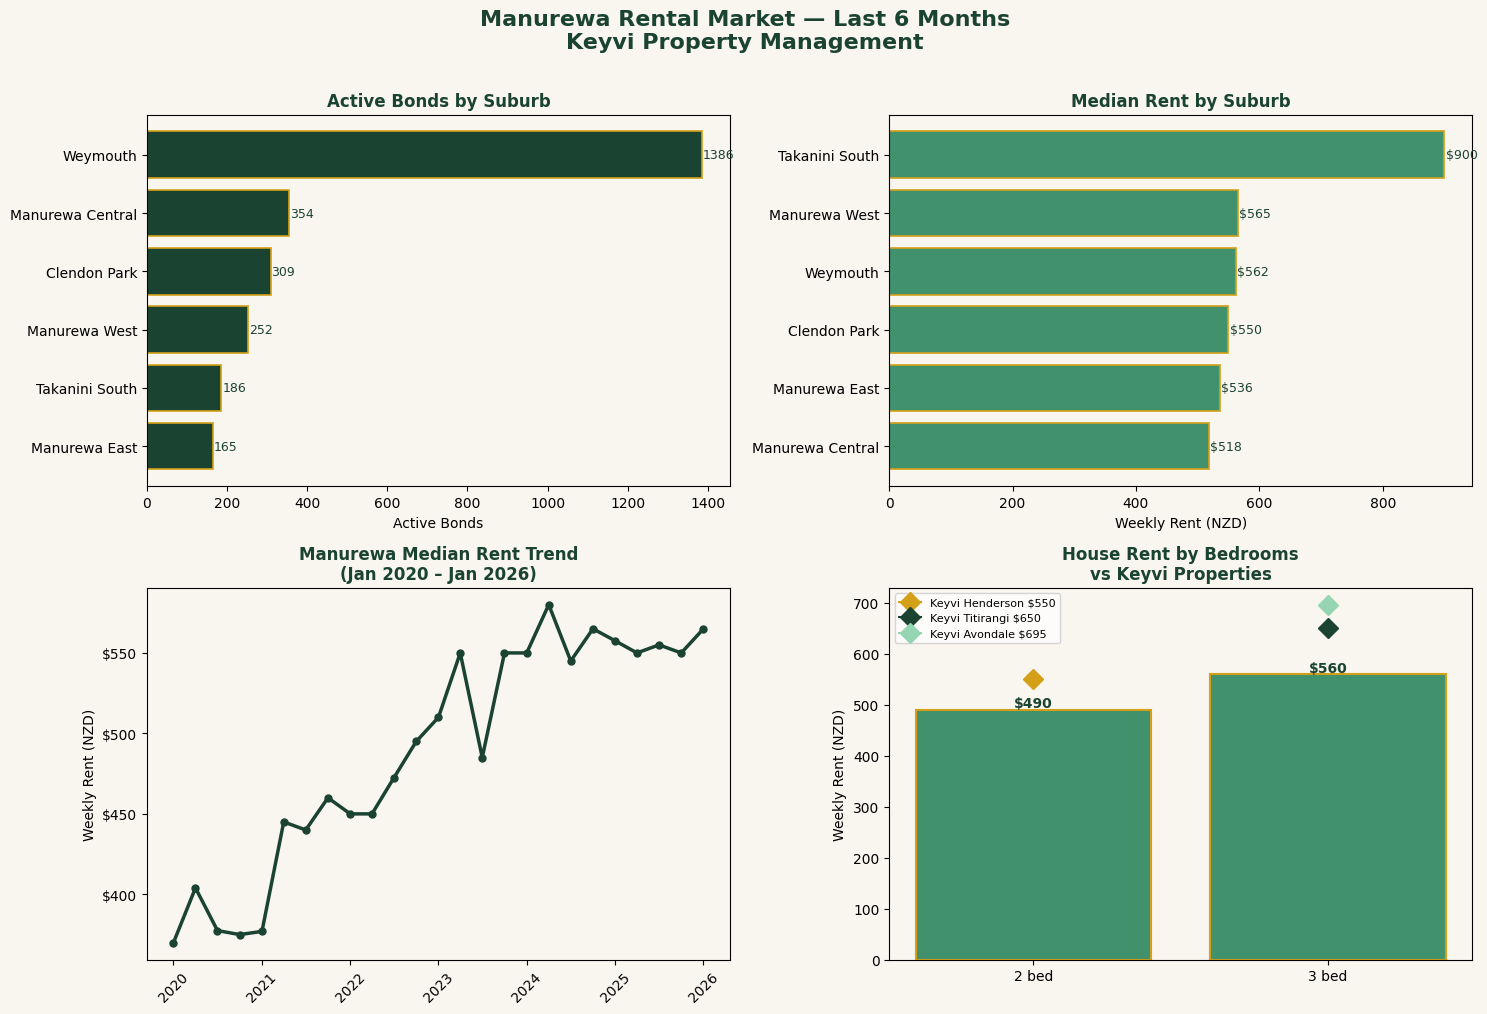

✓ Chart saved as manurewa_analysis.png


In [25]:
# ── Charts ────────────────────────────────────────────────────

FOREST = '#1B4332'
SAGE   = '#40916C'
GOLD   = '#D4A017'
CREAM  = '#F9F5EF'

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.patch.set_facecolor(CREAM)
fig.suptitle('Manurewa Rental Market — Last 6 Months\nKeyvi Property Management',
             fontsize=16, fontweight='bold', color=FOREST, y=1.01)

# Chart 1 — Active bonds by suburb
ax1 = axes[0, 0]
sub_active = summary['Active_Bonds'].sort_values()
bars = ax1.barh(sub_active.index, sub_active.values,
                color=FOREST, edgecolor=GOLD, linewidth=1.2)
for bar, val in zip(bars, sub_active.values):
    ax1.text(val + 2, bar.get_y() + bar.get_height()/2,
             f'{val:.0f}', va='center', fontsize=9, color=FOREST)
ax1.set_title('Active Bonds by Suburb', fontweight='bold', color=FOREST)
ax1.set_xlabel('Active Bonds')
ax1.set_facecolor(CREAM)

# Chart 2 — Median rent by suburb
ax2 = axes[0, 1]
sub_rent = summary['Median_Rent'].sort_values()
bars2 = ax2.barh(sub_rent.index, sub_rent.values,
                 color=SAGE, edgecolor=GOLD, linewidth=1.2)
for bar, val in zip(bars2, sub_rent.values):
    ax2.text(val + 2, bar.get_y() + bar.get_height()/2,
             f'${val:.0f}', va='center', fontsize=9, color=FOREST)
ax2.set_title('Median Rent by Suburb', fontweight='bold', color=FOREST)
ax2.set_xlabel('Weekly Rent (NZD)')
ax2.set_facecolor(CREAM)

# Chart 3 — Rent trend over time
ax3 = axes[1, 0]
ax3.plot(monthly.index, monthly['Rent'],
         color=FOREST, linewidth=2.5, marker='o', markersize=5)
ax3.set_title('Manurewa Median Rent Trend\n(Jan 2020 – Jan 2026)',
              fontweight='bold', color=FOREST)
ax3.set_ylabel('Weekly Rent (NZD)')
ax3.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x:.0f}'))
ax3.tick_params(axis='x', rotation=45)
ax3.set_facecolor(CREAM)

# Chart 4 — Houses by bedrooms vs Keyvi
ax4 = axes[1, 1]
beds_data   = houses[houses.index.isin([2, 3, 4])]['Median_Rent']
bed_labels  = [f'{int(b)} bed' for b in beds_data.index]
bars4       = ax4.bar(bed_labels, beds_data.values,
                      color=SAGE, edgecolor=GOLD, linewidth=1.5)

# Keyvi properties overlay
keyvi_props = [(2, 550, 'Henderson'), (3, 650, 'Titirangi'),
               (3, 695, 'Avondale'),  (4, 850, 'Westmere')]
colours     = [GOLD, FOREST, '#95D5B2', '#D8F3DC']

for (beds, rent, suburb), colour in zip(keyvi_props, colours):
    label = f'{beds} bed'
    if label in bed_labels:
        idx = bed_labels.index(label)
        ax4.plot(idx, rent, marker='D', markersize=10,
                 color=colour, zorder=5, label=f'Keyvi {suburb} ${rent}')

for bar, val in zip(bars4, beds_data.values):
    ax4.text(bar.get_x() + bar.get_width()/2, val + 5,
             f'${val:.0f}', ha='center', fontweight='bold', color=FOREST)

ax4.set_title('House Rent by Bedrooms\nvs Keyvi Properties',
              fontweight='bold', color=FOREST)
ax4.set_ylabel('Weekly Rent (NZD)')
ax4.legend(fontsize=8)
ax4.set_facecolor(CREAM)

plt.tight_layout()
plt.savefig('manurewa_analysis.png', dpi=150,
            bbox_inches='tight', facecolor=CREAM)
plt.show()
print('✓ Chart saved as manurewa_analysis.png')

In [26]:
# ── Final report ─────────────────────────────────────────────

area_median = summary['Median_Rent'].median()
area_active = summary['Active_Bonds'].sum()
area_closed = summary['Closed_Bonds'].sum()

print('=' * 65)
print('  KEYVI INTELLIGENCE REPORT — MANUREWA AREA')
print(f'  {last_6[0].strftime("%b %Y")} to {last_6[-1].strftime("%b %Y")}')
print('=' * 65)
print()
print('MARKET OVERVIEW')
print(f'  Active rental bonds:   {area_active:,.0f}')
print(f'  Closed bonds:          {area_closed:,.0f}')
print(f'  Turnover rate:         '
      f'{area_closed/area_active*100:.1f}% of active bonds closed')
print(f'  Area median rent:      ${area_median:,.0f}/week')
print()
print('SUBURB BREAKDOWN')
print('-' * 65)
for suburb, row in summary.iterrows():
    print(f'  {suburb:20}  '
          f'Active: {row["Active_Bonds"]:5.0f}  '
          f'Closed: {row["Closed_Bonds"]:4.0f}  '
          f'Median: ${row["Median_Rent"]:,.0f}/wk')
print()
print('KEYVI PORTFOLIO vs MANUREWA MARKET')
print('-' * 65)
for name, beds, rent in [('Henderson', 2, 550), ('Titirangi',  3, 650),
                          ('Avondale',  3, 695), ('Westmere',   4, 850)]:
    market = houses['Median_Rent'].get(beds, area_median)
    diff   = rent - market
    status = '▲ above' if diff > 0 else '▼ below'
    print(f'  {name:12} {beds}bed  ${rent}/wk  '
          f'{status} {beds}bed market median '
          f'(${abs(diff):.0f})')
print()
print(f'  Source: Tenancy Services MBIE — data.govt.nz')
print(f'  Generated: {pd.Timestamp.now().strftime("%d %B %Y")}')
print('=' * 65)

  KEYVI INTELLIGENCE REPORT — MANUREWA AREA
  Oct 2025 to Jan 2026

MARKET OVERVIEW
  Active rental bonds:   2,652
  Closed bonds:          207
  Turnover rate:         7.8% of active bonds closed
  Area median rent:      $556/week

SUBURB BREAKDOWN
-----------------------------------------------------------------
  Weymouth              Active:  1386  Closed:  108  Median: $562/wk
  Manurewa Central      Active:   354  Closed:   24  Median: $518/wk
  Clendon Park          Active:   309  Closed:   27  Median: $550/wk
  Manurewa West         Active:   252  Closed:   18  Median: $565/wk
  Takanini South        Active:   186  Closed:   18  Median: $900/wk
  Manurewa East         Active:   165  Closed:   12  Median: $536/wk

KEYVI PORTFOLIO vs MANUREWA MARKET
-----------------------------------------------------------------
  Henderson    2bed  $550/wk  ▲ above 2bed market median ($60)
  Titirangi    3bed  $650/wk  ▲ above 3bed market median ($90)
  Avondale     3bed  $695/wk  ▲ above 3bed

In [27]:
# ── Top 5 and Bottom 5 for Total, Active and Closed Bonds ───

# Need ALL suburbs — not just Manurewa
# Use full dataset, last period (Jan 2026), ALL dwelling types

latest_period = df['TimeFrame'].max()

df_latest = df[
    (df['TimeFrame'] == latest_period) &
    (df['Dwelling Type'] == 'ALL') &
    (df['Location Id'] > 0)          # remove NaN and -99 (national totals)
].copy()

# Add suburb names for known codes
df_latest['Suburb'] = df_latest['Location Id'].map(MANUREWA_CODES).fillna(
    df_latest['Location Id'].astype(int).astype(str)
)

print(f'Analysis period: {latest_period.strftime("%b %Y")}')
print(f'Total suburbs:   {len(df_latest):,}')
print()

for metric, label, unit in [
    ('Total Bonds',  'NEW TENANCIES STARTED',  'bonds'),
    ('Active Bonds', 'CURRENTLY RENTED',        'bonds'),
    ('Closed Bonds', 'TENANCIES ENDED',         'bonds'),
]:
    col_clean = df_latest[metric].dropna()
    
    top5    = df_latest.nlargest(5, metric)[['Suburb', metric]]
    bottom5 = df_latest.nsmallest(5, metric)[['Suburb', metric]]

    print('=' * 55)
    print(f'  {metric.upper()} — {label}')
    print('=' * 55)

    print(f'  TOP 5 (most {unit}):')
    for _, row in top5.iterrows():
        bar = '█' * int(row[metric] / top5[metric].max() * 20)
        print(f'    {str(row["Suburb"]):15}  {row[metric]:6,.0f}  {bar}')

    print()
    print(f'  BOTTOM 5 (least {unit}):')
    for _, row in bottom5.iterrows():
        bar = '█' * max(1, int(row[metric] / top5[metric].max() * 20))
        print(f'    {str(row["Suburb"]):15}  {row[metric]:6,.0f}  {bar}')
    print()

Analysis period: Jan 2026
Total suburbs:   4,151

  TOTAL BONDS — NEW TENANCIES STARTED
  TOP 5 (most bonds):
    134800              648  ████████████████████
    134800              645  ███████████████████
    352200              534  ████████████████
    251600              318  █████████
    179900              294  █████████

  BOTTOM 5 (least bonds):
    100200                6  █
    100400                6  █
    100700                6  █
    100800                6  █
    105300                6  █

  ACTIVE BONDS — CURRENTLY RENTED
  TOP 5 (most bonds):
    179900            1,689  ████████████████████
    251600            1,665  ███████████████████
    327900            1,581  ██████████████████
    136000            1,395  ████████████████
    325300            1,344  ███████████████

  BOTTOM 5 (least bonds):
    100200                6  █
    105300                6  █
    126000                6  █
    153100                6  █
    176900                6  █

  CLOSE

In [29]:
# ── Known SA2 names + fetch the rest ────────────────────────

# Partial lookup — known codes from Stats NZ 2019
SA2_NAMES = {
    # Manurewa area
    215700: 'Manurewa West',
    215800: 'Manurewa Central',
    215900: 'Manurewa East',
    216000: 'Clendon Park',
    216100: 'Wattle Downs',
    216300: 'Weymouth',
    216500: 'Takanini South',
    # Top codes from results
    134800: 'Auckland CBD',
    136000: 'Ponsonby',
    179900: 'Papatoetoe East',
    251600: 'Newtown (Wellington)',
    327900: 'Christchurch Central',
    325300: 'Riccarton (Christchurch)',
    352200: 'Dunedin Central',
    352400: 'South Dunedin',
    353200: 'Brockville (Dunedin)',
}

# Try Stats NZ geographic names CSV
print('Trying Stats NZ SA2 lookup...')
try:
    r = requests.get(
        'https://raw.githubusercontent.com/mbie/market-rent-data/main/sa2-2019-names.csv',
        timeout=10
    )
    if r.status_code == 200:
        df_sa2 = pd.read_csv(io.StringIO(r.text))
        print('✓ Found:', df_sa2.columns.tolist())
    else:
        raise Exception('Not found')
except:
    # Try LINZ
    print('Trying LINZ...')
    try:
        r2 = requests.get(
            'https://data.linz.govt.nz/layer/92210-statistical-area-2-2019-generalised/data.csv',
            timeout=10
        )
        print('LINZ status:', r2.status_code)
    except Exception as e:
        print(f'LINZ failed: {e}')
    
    print()
    print('Using partial lookup for now.')
    print('Full names available tomorrow with Market Rent API key.')

# Apply names to results
df_latest['Suburb Name'] = df_latest['Location Id'].map(SA2_NAMES).fillna(
    'SA2-' + df_latest['Location Id'].astype(int).astype(str)
)

# Reprint top/bottom 5 with names
for metric, label in [
    ('Total Bonds',  'NEW TENANCIES STARTED'),
    ('Active Bonds', 'CURRENTLY RENTED'),
    ('Closed Bonds', 'TENANCIES ENDED'),
]:
    top5    = df_latest.nlargest(5, metric)[['Suburb Name', 'Location Id', metric]]
    bottom5 = df_latest.nsmallest(5, metric)[['Suburb Name', 'Location Id', metric]]

    print('=' * 60)
    print(f'  {metric.upper()} — {label}')
    print('=' * 60)
    print(f'  TOP 5:')
    for _, row in top5.iterrows():
        print(f'    {str(row["Suburb Name"]):30}  {row[metric]:6,.0f}')
    print(f'  BOTTOM 5:')
    for _, row in bottom5.iterrows():
        print(f'    {str(row["Suburb Name"]):30}  {row[metric]:6,.0f}')
    print()

Trying Stats NZ SA2 lookup...
Trying LINZ...
LINZ status: 200

Using partial lookup for now.
Full names available tomorrow with Market Rent API key.
  TOTAL BONDS — NEW TENANCIES STARTED
  TOP 5:
    Auckland CBD                       648
    Auckland CBD                       645
    Dunedin Central                    534
    Newtown (Wellington)               318
    Papatoetoe East                    294
  BOTTOM 5:
    SA2-100200                           6
    SA2-100400                           6
    SA2-100700                           6
    SA2-100800                           6
    SA2-105300                           6

  ACTIVE BONDS — CURRENTLY RENTED
  TOP 5:
    Papatoetoe East                  1,689
    Newtown (Wellington)             1,665
    Christchurch Central             1,581
    Ponsonby                         1,395
    Riccarton (Christchurch)         1,344
  BOTTOM 5:
    SA2-100200                           6
    SA2-105300                           6
    S

In [30]:
# ── Auckland SA2 code range ──────────────────────────────────
# Stats NZ 2019: Auckland region codes are 125000 to 219999

df_auckland = df_latest[
    (df_latest['Location Id'] >= 125000) &
    (df_latest['Location Id'] <= 219999)
].copy()

print(f'Auckland suburbs found: {len(df_auckland)}')
print()

for metric, label in [
    ('Total Bonds',  'NEW TENANCIES STARTED'),
    ('Active Bonds', 'CURRENTLY RENTED'),
    ('Closed Bonds', 'TENANCIES ENDED'),
]:
    top5    = df_auckland.nlargest(5, metric)[['Suburb Name', metric]]
    bottom5 = df_auckland.nsmallest(5, metric)[['Suburb Name', metric]]

    print('=' * 60)
    print(f'  {metric.upper()} — {label}')
    print('=' * 60)
    print(f'  TOP 5:')
    for _, row in top5.iterrows():
        bar = '█' * int(row[metric] / top5[metric].max() * 20)
        print(f'    {str(row["Suburb Name"]):30}  {row[metric]:6,.0f}  {bar}')
    print()
    print(f'  BOTTOM 5:')
    for _, row in bottom5.iterrows():
        bar = '█' * max(1, int(row[metric] / top5[metric].max() * 20))
        print(f'    {str(row["Suburb Name"]):30}  {row[metric]:6,.0f}  {bar}')
    print()

Auckland suburbs found: 1974

  TOTAL BONDS — NEW TENANCIES STARTED
  TOP 5:
    Auckland CBD                       648  ████████████████████
    Auckland CBD                       645  ███████████████████
    Papatoetoe East                    294  █████████
    SA2-135100                         288  ████████
    SA2-135900                         279  ████████

  BOTTOM 5:
    SA2-125000                           6  █
    SA2-125300                           6  █
    SA2-125400                           6  █
    SA2-126000                           6  █
    SA2-126300                           6  █

  ACTIVE BONDS — CURRENTLY RENTED
  TOP 5:
    Papatoetoe East                  1,689  ████████████████████
    Ponsonby                         1,395  ████████████████
    SA2-133400                       1,203  ██████████████
    SA2-146300                       1,200  ██████████████
    SA2-135100                       1,179  █████████████

  BOTTOM 5:
    SA2-126000                  

In [31]:
# ── Add more Auckland SA2 names ──────────────────────────────

SA2_NAMES.update({
    # Inner Auckland
    135100: 'Grafton',
    135900: 'Mount Eden',
    135300: 'Epsom',
    134500: 'Parnell',
    133400: 'Newmarket',
    134800: 'Auckland CBD',

    # Eastern Auckland
    146300: 'Howick',
    153100: 'Cockle Bay',

    # Rodney (northernmost Auckland)
    125000: 'Wellsford',
    125300: 'Leigh',
    125400: 'Matakana',
    125700: 'Omaha',
    125800: 'Whangateau',
    125900: 'Mahurangi East',
    126000: 'Warkworth',
    126300: 'Snells Beach',

    # South Auckland
    176900: 'Manurewa North',
    208100: 'Karaka',
    213100: 'Pukekohe East',
})

# Reapply names
df_auckland['Suburb Name'] = df_auckland['Location Id'].map(SA2_NAMES).fillna(
    'SA2-' + df_auckland['Location Id'].astype(int).astype(str)
)

# Reprint
for metric, label in [
    ('Total Bonds',  'NEW TENANCIES STARTED'),
    ('Active Bonds', 'CURRENTLY RENTED'),
    ('Closed Bonds', 'TENANCIES ENDED'),
]:
    top5    = df_auckland.nlargest(5, metric)[['Suburb Name', metric]]
    bottom5 = df_auckland.nsmallest(5, metric)[['Suburb Name', metric]]

    print('=' * 60)
    print(f'  {metric.upper()} — {label}')
    print('=' * 60)
    print('  TOP 5:')
    for _, row in top5.iterrows():
        bar = '█' * int(row[metric] / top5[metric].max() * 20)
        print(f'    {str(row["Suburb Name"]):30}  {row[metric]:6,.0f}  {bar}')
    print()
    print('  BOTTOM 5:')
    for _, row in bottom5.iterrows():
        bar = '█' * max(1, int(row[metric] / top5[metric].max() * 20))
        print(f'    {str(row["Suburb Name"]):30}  {row[metric]:6,.0f}  {bar}')
    print()

# Check remaining unknown codes
unknown = df_auckland[
    df_auckland['Suburb Name'].str.startswith('SA2-')
]['Location Id'].unique()
print(f'Still unknown: {len(unknown)} suburb codes')
print('Get all names tomorrow with Market Rent API key')

  TOTAL BONDS — NEW TENANCIES STARTED
  TOP 5:
    Auckland CBD                       648  ████████████████████
    Auckland CBD                       645  ███████████████████
    Papatoetoe East                    294  █████████
    Grafton                            288  ████████
    Mount Eden                         279  ████████

  BOTTOM 5:
    Wellsford                            6  █
    Leigh                                6  █
    Matakana                             6  █
    Warkworth                            6  █
    Snells Beach                         6  █

  ACTIVE BONDS — CURRENTLY RENTED
  TOP 5:
    Papatoetoe East                  1,689  ████████████████████
    Ponsonby                         1,395  ████████████████
    Newmarket                        1,203  ██████████████
    Howick                           1,200  ██████████████
    Grafton                          1,179  █████████████

  BOTTOM 5:
    Warkworth                            6  █
    Cockle Bay  

Papatoetoe East — Last 3 Years
Periods: Jul 2023 to Jan 2026
Quarters: 73

 TimeFrame  Total Bonds  Active Bonds  Closed Bonds  Median Rent
2023-07-01           24           336            21          460
2023-07-01           27           282            27          560
2023-07-01           96           612            90          260
2023-07-01           15            72             3          660
2023-07-01          171          1575           153          318
2023-07-01            6           171             6          800
2023-10-01           27           336            27          458
2023-10-01          120           585           147          255
2023-10-01           27           279            30          578
2023-10-01           21           159            33          673
2023-10-01            6            66            12          410
2023-10-01            6            87            18          750
2023-10-01          210          1518           267          340
2024-01-01     

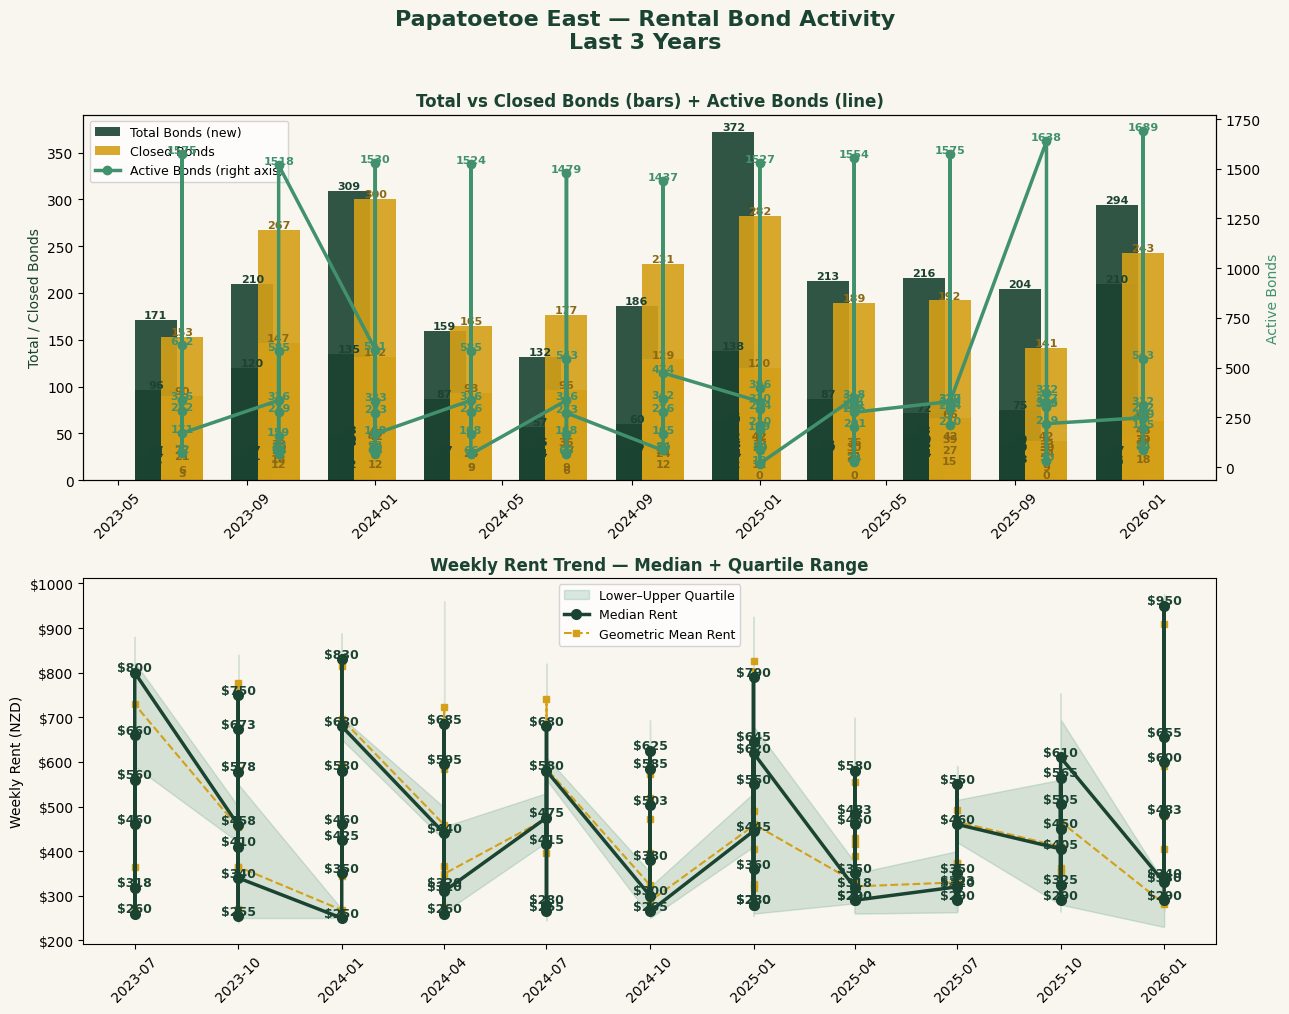

✓ Chart saved as papatoetoe_east_3yr.png


In [32]:
# ── Papatoetoe East — Last 3 Years ──────────────────────────

PAPATOETOE_CODE = 179900

# Filter
pap = df[
    (df['Location Id'] == PAPATOETOE_CODE) &
    (df['Dwelling Type'] == 'ALL')
].sort_values('TimeFrame').copy()

# Last 3 years
three_years_ago = pd.Timestamp.now() - pd.DateOffset(years=3)
pap3 = pap[pap['TimeFrame'] >= three_years_ago].copy()

print(f'Papatoetoe East — Last 3 Years')
print(f'Periods: {pap3["TimeFrame"].min().strftime("%b %Y")} '
      f'to {pap3["TimeFrame"].max().strftime("%b %Y")}')
print(f'Quarters: {len(pap3)}')
print()
print(pap3[['TimeFrame', 'Total Bonds', 'Active Bonds',
            'Closed Bonds', 'Median Rent']].to_string(index=False))

# ── Chart ────────────────────────────────────────────────────
FOREST = '#1B4332'
SAGE   = '#40916C'
GOLD   = '#D4A017'
CREAM  = '#F9F5EF'

fig, axes = plt.subplots(2, 1, figsize=(13, 10))
fig.patch.set_facecolor(CREAM)
fig.suptitle('Papatoetoe East — Rental Bond Activity\nLast 3 Years',
             fontsize=16, fontweight='bold', color=FOREST, y=1.01)

dates = pap3['TimeFrame']

# ── Chart 1 — Total, Active, Closed Bonds ────────────────────
ax1 = axes[0]
ax1_twin = ax1.twinx()

width = 40  # bar width in days

ax1.bar(dates - pd.Timedelta(days=25),
        pap3['Total Bonds'],
        width=width, color=FOREST,
        label='Total Bonds (new)', alpha=0.9)

ax1.bar(dates,
        pap3['Closed Bonds'],
        width=width, color=GOLD,
        label='Closed Bonds', alpha=0.9)

ax1_twin.plot(dates, pap3['Active Bonds'],
              color=SAGE, linewidth=2.5,
              marker='o', markersize=6,
              label='Active Bonds (right axis)')

# Add value labels on bars
for _, row in pap3.iterrows():
    ax1.text(row['TimeFrame'] - pd.Timedelta(days=25),
             row['Total Bonds'] + 2,
             f'{row["Total Bonds"]:.0f}',
             ha='center', fontsize=8, color=FOREST, fontweight='bold')
    ax1.text(row['TimeFrame'],
             row['Closed Bonds'] + 2,
             f'{row["Closed Bonds"]:.0f}',
             ha='center', fontsize=8, color='#8B6914', fontweight='bold')
    ax1_twin.text(row['TimeFrame'],
                  row['Active Bonds'] + 5,
                  f'{row["Active Bonds"]:.0f}',
                  ha='center', fontsize=8, color=SAGE, fontweight='bold')

ax1.set_title('Total vs Closed Bonds (bars) + Active Bonds (line)',
              fontweight='bold', color=FOREST, fontsize=12)
ax1.set_ylabel('Total / Closed Bonds', color=FOREST)
ax1_twin.set_ylabel('Active Bonds', color=SAGE)
ax1.set_facecolor(CREAM)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_twin.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc='upper left', fontsize=9)
ax1.tick_params(axis='x', rotation=45)

# ── Chart 2 — Median Rent Trend ──────────────────────────────
ax2 = axes[1]

ax2.fill_between(dates,
                 pap3['Lower Quartile Rent'],
                 pap3['Upper Quartile Rent'],
                 alpha=0.2, color=SAGE, label='Lower–Upper Quartile')

ax2.plot(dates, pap3['Median Rent'],
         color=FOREST, linewidth=2.5,
         marker='o', markersize=7,
         label='Median Rent', zorder=5)

ax2.plot(dates, pap3['Geometric Mean Rent'],
         color=GOLD, linewidth=1.5,
         linestyle='--', marker='s', markersize=5,
         label='Geometric Mean Rent')

# Add value labels
for _, row in pap3.iterrows():
    ax2.text(row['TimeFrame'],
             row['Median Rent'] + 3,
             f'${row["Median Rent"]:.0f}',
             ha='center', fontsize=9,
             fontweight='bold', color=FOREST)

ax2.set_title('Weekly Rent Trend — Median + Quartile Range',
              fontweight='bold', color=FOREST, fontsize=12)
ax2.set_ylabel('Weekly Rent (NZD)')
ax2.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x:.0f}'))
ax2.set_facecolor(CREAM)
ax2.legend(fontsize=9)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('papatoetoe_east_3yr.png', dpi=150,
            bbox_inches='tight', facecolor=CREAM)
plt.show()
print('✓ Chart saved as papatoetoe_east_3yr.png')